<a href="https://colab.research.google.com/gist/joao5142/cb1f0ffaa02635e7b06a6163bf1a0570/ml-pucrio-sprint-4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Bibliotecas
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from imblearn.over_sampling import SMOTE

import pickle


In [3]:
# Carrega Dataset
url = 'https://gist.githubusercontent.com/joao5142/2ab68d087b211c81990617b21f002972/raw/abcc440ff6b88dd8bb7611ef59459a8ffb7c8849/water_quality.csv'

dataset = pd.read_csv(url)

print(dataset.shape)

(3276, 10)


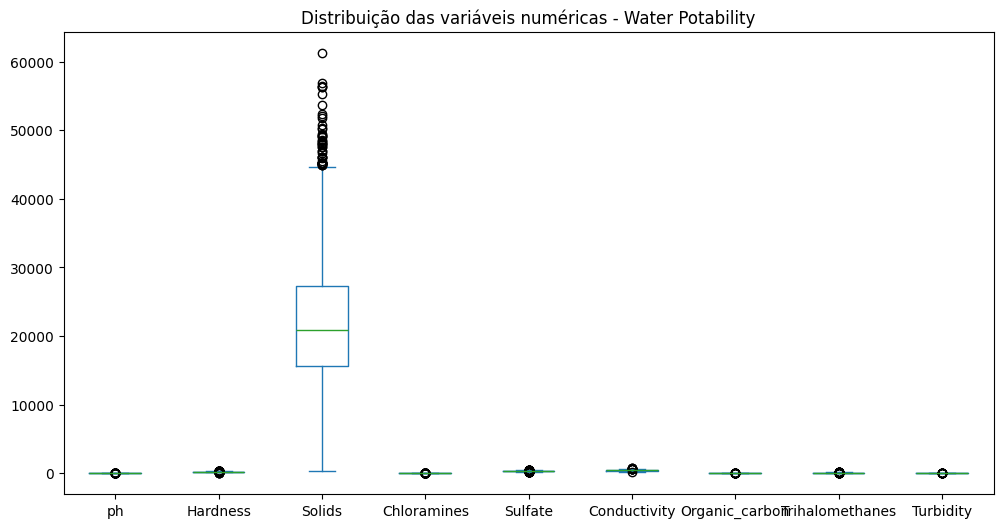

Potability
0    1998
1    1278
Name: count, dtype: int64


In [4]:
# Gera Graficos e ver balanceamento do dataset
dataset[[
    "ph",
    "Hardness",
    "Solids",
    "Chloramines",
    "Sulfate",
    "Conductivity",
    "Organic_carbon",
    "Trihalomethanes",
    "Turbidity"
]].plot(
    kind="box",
    figsize=(12, 6)
)

plt.title("Distribuição das variáveis numéricas - Water Potability")
plt.show()

print(dataset["Potability"].value_counts())

In [5]:
# Tratar datasets - Algumas colunas não tem valores
dataset = dataset.fillna(0)

In [6]:
# Holdout separar treino e teste

# separar X e Y - Potability é o que quero testar
X = dataset.drop("Potability", axis=1)
Y = dataset["Potability"]

# split 70/30
X_train, X_validation, Y_train, Y_validation = train_test_split(X, Y, test_size=0.30, random_state=7)

In [7]:
# Problema de classificação , vai utilizar pela acuracia
scoring = 'accuracy'
modelos = []

modelos.append(('KNN', KNeighborsClassifier()))
modelos.append(('CART', DecisionTreeClassifier()))
modelos.append(('NB', GaussianNB()))
modelos.append(('SVM', SVC()))

resultados = []
nomes = []

kfold = KFold(n_splits=10, shuffle=True, random_state=7)



for nome_modelo, modelo in modelos:


    cv_resultados = cross_val_score(
        modelo,
        X_train,
        Y_train,
        cv=kfold,
        scoring=scoring
    )

    resultados.append(cv_resultados)
    nomes.append(nome_modelo)

    msg = "%s: %f (%f)" % (
        nome_modelo,
        cv_resultados.mean(),
        cv_resultados.std()
    )

    print(msg)

KNN: 0.566501 (0.019850)
CART: 0.595305 (0.029181)
NB: 0.619658 (0.034719)
SVM: 0.617492 (0.031926)


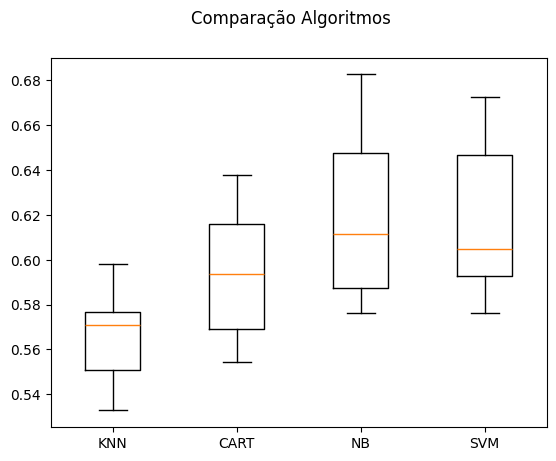

In [8]:
# Comparar Algoritmos visualmente
figura = plt.figure()
figura.suptitle("Comparação Algoritmos")

ax = figura.add_subplot(111)
plt.boxplot(resultados)
ax.set_xticklabels(nomes)

plt.show()

KNN-orig: 0.567 (0.020)
CART-orig: 0.591 (0.031)
NB-orig: 0.620 (0.035)
SVM-orig: 0.617 (0.032)
KNN-padr: 0.587 (0.030)
CART-padr: 0.594 (0.021)
NB-padr: 0.618 (0.033)
SVM-padr: 0.646 (0.040)
RF-padr: 0.670 (0.032)
GB-padr: 0.637 (0.025)
KNN-norm: 0.617 (0.030)
CART-norm: 0.590 (0.032)
NB-norm: 0.618 (0.033)
SVM-norm: 0.654 (0.036)
RF-norm: 0.671 (0.032)
GB-norm: 0.637 (0.025)


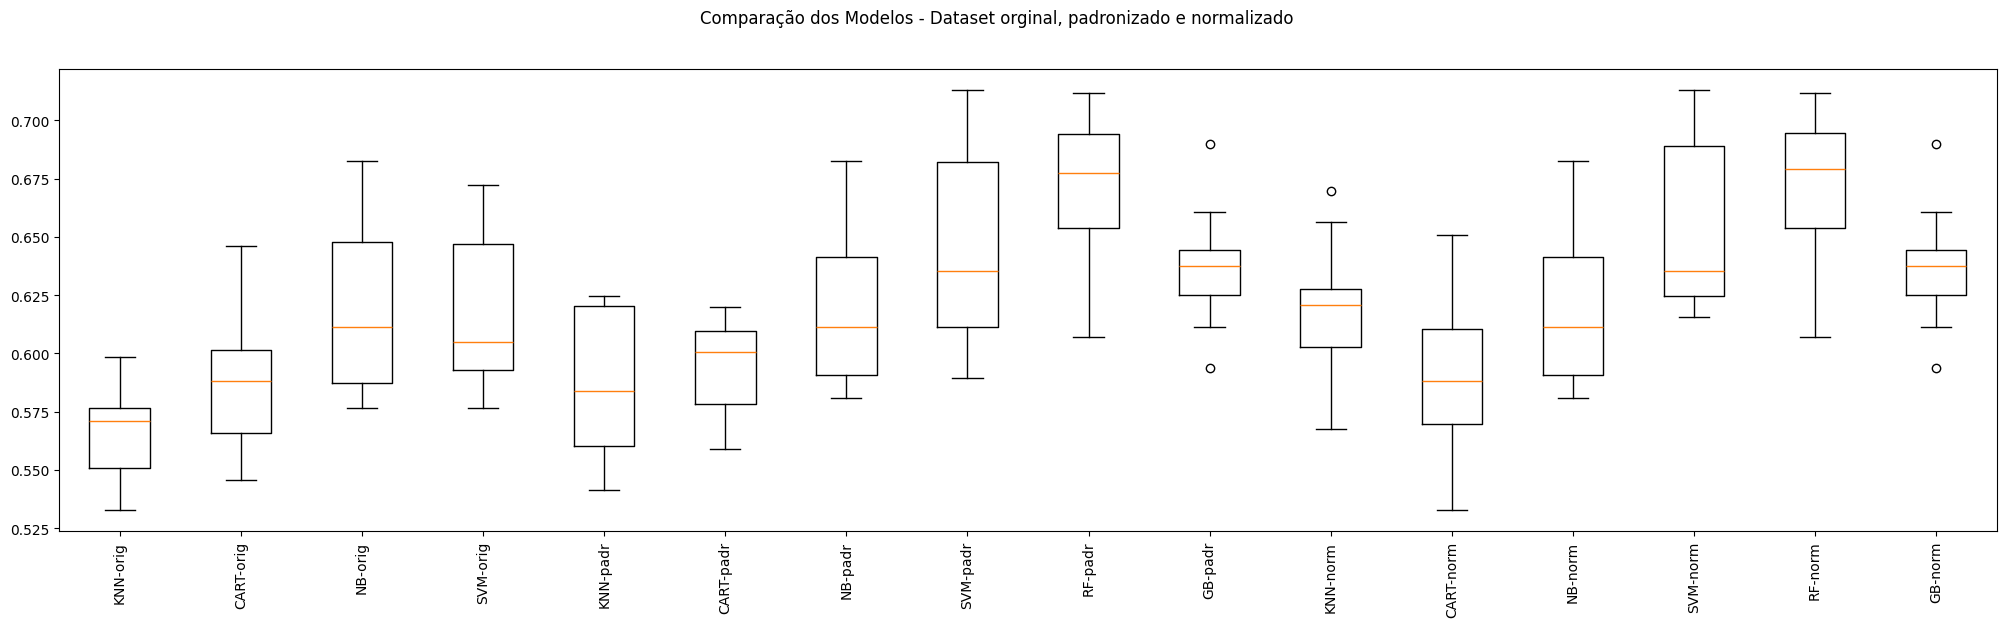

In [9]:
# Melhorar mais o modelo - Resultado entre 50 - 60 sem normalização

np.random.seed(7) # definindo uma semente global para este bloco

# Listas para armazenar os armazenar os pipelines e os resultados para todas as visões do dataset
pipelines = []
resultados = []
nomes_modelos = []


# Algoritmos que serão utilizados
knn = ('KNN', KNeighborsClassifier())
cart = ('CART', DecisionTreeClassifier())
naive_bayes = ('NB', GaussianNB())
svm = ('SVM', SVC())

# Transformações que serão utilizadas
normalizacao_standard_scaler = ('StandardScaler', StandardScaler())
normalizacao_min_max_scaler = ('MinMaxScaler', MinMaxScaler())


# Montando os pipelines

# Dataset original
pipelines.append(('KNN-orig', Pipeline([knn])))
pipelines.append(('CART-orig', Pipeline([cart])))
pipelines.append(('NB-orig', Pipeline([naive_bayes])))
pipelines.append(('SVM-orig', Pipeline([svm])))

# Dataset Padronizado
pipelines.append(('KNN-padr', Pipeline([normalizacao_standard_scaler, knn])))
pipelines.append(('CART-padr', Pipeline([normalizacao_standard_scaler, cart])))
pipelines.append(('NB-padr', Pipeline([normalizacao_standard_scaler, naive_bayes])))
pipelines.append(('SVM-padr', Pipeline([normalizacao_standard_scaler, svm])))
pipelines.append(('RF-padr', Pipeline([normalizacao_standard_scaler, ('RF', RandomForestClassifier(n_estimators=200, random_state=7))])))
pipelines.append(('GB-padr', Pipeline([normalizacao_standard_scaler, ('GB', GradientBoostingClassifier(n_estimators=200, random_state=7))])))


# Dataset Normalizado
pipelines.append(('KNN-norm', Pipeline([normalizacao_min_max_scaler, knn])))
pipelines.append(('CART-norm', Pipeline([normalizacao_min_max_scaler, cart])))
pipelines.append(('NB-norm', Pipeline([normalizacao_min_max_scaler, naive_bayes])))
pipelines.append(('SVM-norm', Pipeline([normalizacao_min_max_scaler, svm])))
pipelines.append(('RF-norm', Pipeline([normalizacao_min_max_scaler, ('RF', RandomForestClassifier(n_estimators=200, random_state=7))])))
pipelines.append(('GB-norm', Pipeline([normalizacao_min_max_scaler, ('GB', GradientBoostingClassifier(n_estimators=200, random_state=7))])))

# Executando os pipelines
for nome, modelo in pipelines:
    cv_results = cross_val_score(modelo, X_train, Y_train, cv=kfold, scoring=scoring)

    resultados.append(cv_results)
    nomes_modelos.append(nome)

    msg = "%s: %.3f (%.3f)" % (nome, cv_results.mean(), cv_results.std())

    print(msg)

# Boxplot de comparação dos modelos
fig = plt.figure(figsize=(25,6))
fig.suptitle('Comparação dos Modelos - Dataset orginal, padronizado e normalizado')
ax = fig.add_subplot(111)
plt.boxplot(resultados)
ax.set_xticklabels(nomes_modelos, rotation=90)
plt.show()

In [10]:
# Modelo selecionado e Previsões
smote = SMOTE(random_state=7)
X_train_bal, Y_train_bal = smote.fit_resample(X_train, Y_train)


print("Treino (após SMOTE):")
print(Y_train_bal.value_counts())

print("\nValidação:")
print(Y_validation.value_counts())

modelo_escolhido = RandomForestClassifier(n_estimators=200, random_state=7)
modelo_escolhido.fit(X_train_bal, Y_train_bal)
previsoes = modelo_escolhido.predict(X_validation)

print("\nAcurácia:", accuracy_score(Y_validation, previsoes))
print("\nMatriz de Confusão:")
print(confusion_matrix(Y_validation, previsoes))
print("\nRelatório:")
print(classification_report(Y_validation, previsoes))

Treino (após SMOTE):
Potability
1    1416
0    1416
Name: count, dtype: int64

Validação:
Potability
0    582
1    401
Name: count, dtype: int64

Acurácia: 0.6215666327568667

Matriz de Confusão:
[[430 152]
 [220 181]]

Relatório:
              precision    recall  f1-score   support

           0       0.66      0.74      0.70       582
           1       0.54      0.45      0.49       401

    accuracy                           0.62       983
   macro avg       0.60      0.60      0.60       983
weighted avg       0.61      0.62      0.61       983



In [11]:
# Tentar prever com um dado não testado

novo_dado_teste = X.iloc[0:1].copy()

novo_dado_teste["ph"] = 7.2
novo_dado_teste["Hardness"] = 13.0
novo_dado_teste["Solids"] = 20.0
novo_dado_teste["Chloramines"] = 7.0
novo_dado_teste["Sulfate"] = 333.0
novo_dado_teste["Conductivity"] = 426.0
novo_dado_teste["Organic_carbon"] = 14.0
novo_dado_teste["Trihalomethanes"] = 66.0
novo_dado_teste["Turbidity"] = 4.0

resultado = modelo_escolhido.predict(novo_dado_teste)
print("Potável" if resultado[0] == 1 else "Não Potável")

Potável


In [13]:
#exportar modelo
with open("../models/modelo_water.pkl", "wb") as file:
    pickle.dump(modelo_escolhido, file)
'''
  Analise do dataset:

  Dataset desbalanceado contendo mais "não potavel" do que "potavel"
  Valores distintos um do outros em grandeza

  Pontos:

  Ao verificar com os algoritmos KNN, NV E SVM tive a impressão que não estava com acurácia ideal e fui para o RF e GB.

  Solução :

  Normalização e transformação dos dados para melhor modelo - uso da padronização de escala
  Balanceamento de dados com SMOTE , visto que tinha mais dados de um lado do que do outro
  Uso do Random Forest


'''

'\n  Analise do dataset:\n\n  Dataset desbalanceado contendo mais "não potavel" do que "potavel"\n  Valores distintos um do outros em grandeza\n\n  Pontos:\n\n  Ao verificar com os algoritmos KNN, NV E SVM tive a impressão que não estava com acurácia ideal e fui para o RF e GB.\n\n  Solução :\n\n  Normalização e transformação dos dados para melhor modelo - uso da padronização de escala\n  Balanceamento de dados com SMOTE , visto que tinha mais dados de um lado do que do outro\n  Uso do Random Forest\n\n\n'